In [37]:
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd 

In [38]:
df=pd.read_csv("../data/raw/credit_risk_dataset.csv")

In [39]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [40]:
df.shape

(32581, 12)

In [41]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [43]:
df.duplicated().sum()

np.int64(165)

In [44]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

In [45]:
# Target columsn is ['loan_status]
df['loan_status'].unique()

array([1, 0])

In [46]:
# Now we will check the class imbalance /Traget balance  
# Below is the google defination 
'''
Target balance refers to an equal or desired distribution of classes in a dataset, 
whereas class imbalance describes a state of unequal representation where one class heavily dominates the other

Target BalanceDefinition: A state where the target or dependent variable has roughly equal numbers of samples for each category 
(e.g., a 50/50 split in binary classification).Goal: To provide a model with balanced learning signals so it does not favor any single category.
Creation: Can be achieved naturally or artificially via resampling methods like SMOTE

Class ImbalanceDefinition: A data distribution problem where one category (the majority class) significantly outnumbers the other category 
(the minority class).Problem: Causes machine learning models to become biased, 
yielding misleadingly high accuracy while failing to predict the minority class.Examples: Fraud detection, rare disease screening, 
and equipment failure prediction
'''

'\nTarget balance refers to an equal or desired distribution of classes in a dataset, \nwhereas class imbalance describes a state of unequal representation where one class heavily dominates the other\n\nTarget BalanceDefinition: A state where the target or dependent variable has roughly equal numbers of samples for each category \n(e.g., a 50/50 split in binary classification).Goal: To provide a model with balanced learning signals so it does not favor any single category.\nCreation: Can be achieved naturally or artificially via resampling methods like SMOTE\n\nClass ImbalanceDefinition: A data distribution problem where one category (the majority class) significantly outnumbers the other category \n(the minority class).Problem: Causes machine learning models to become biased, \nyielding misleadingly high accuracy while failing to predict the minority class.Examples: Fraud detection, rare disease screening, \nand equipment failure prediction\n'

In [47]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

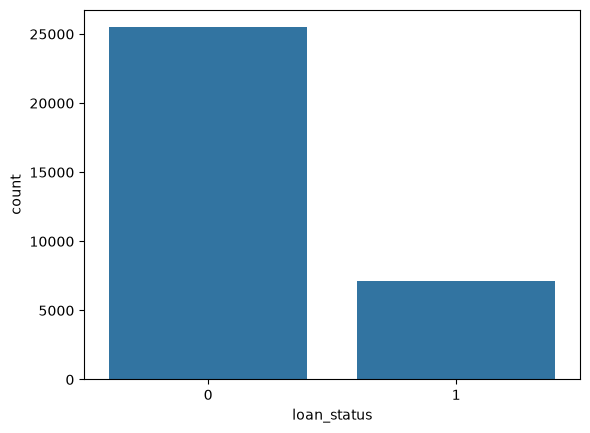

In [48]:
sns.countplot(data=df,x='loan_status')

In [49]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [50]:
# Outliers
'''To check the outliers we will use boxplot but to use tht we nned numerical columns we will extract tht'''

'To check the outliers we will use boxplot but to use tht we nned numerical columns we will extract tht'

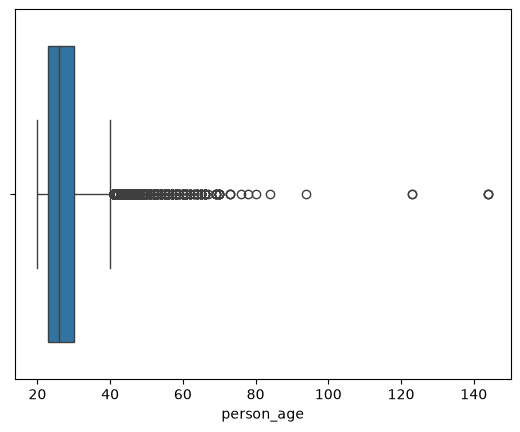

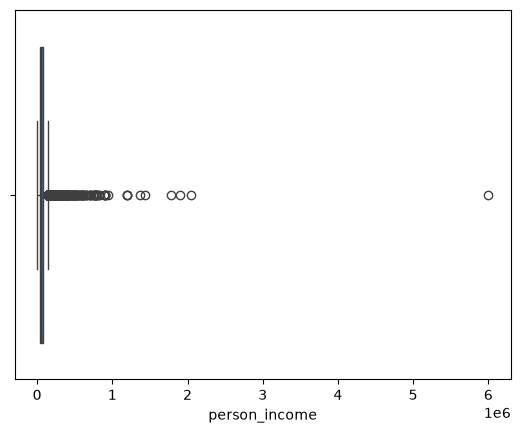

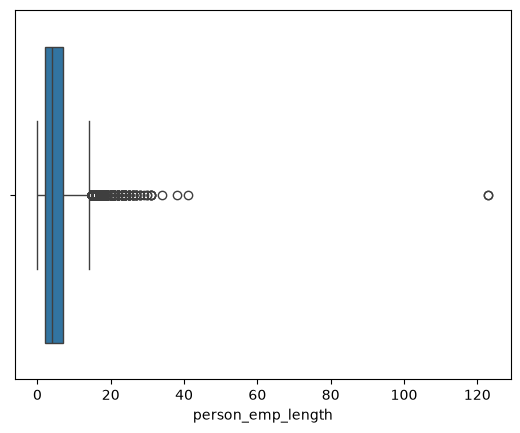

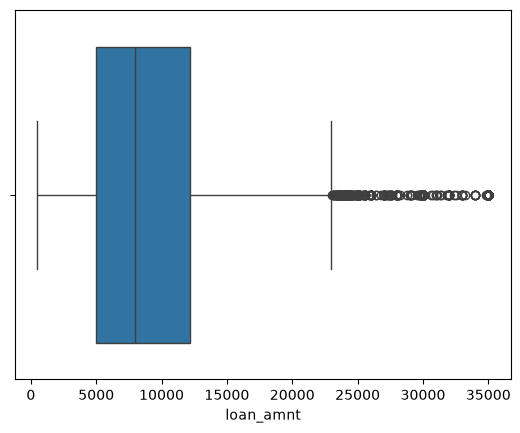

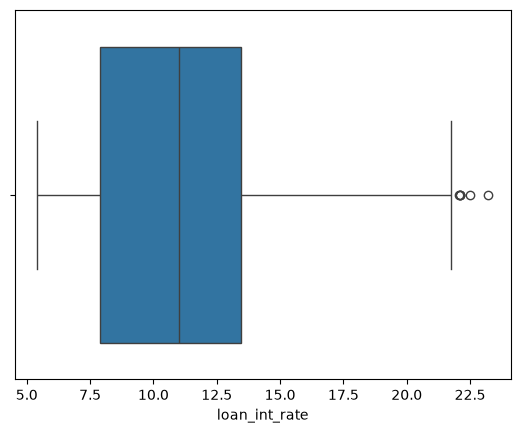

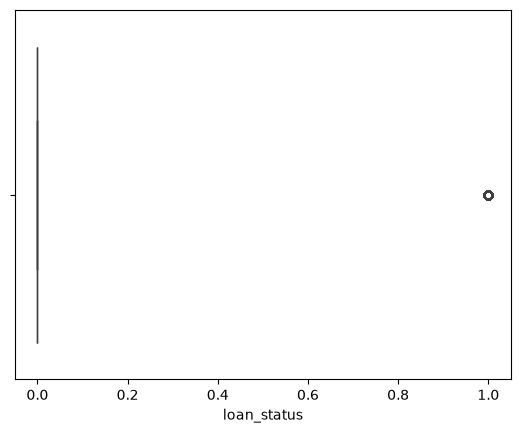

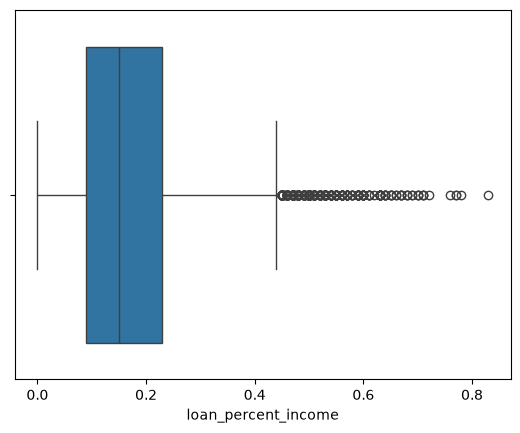

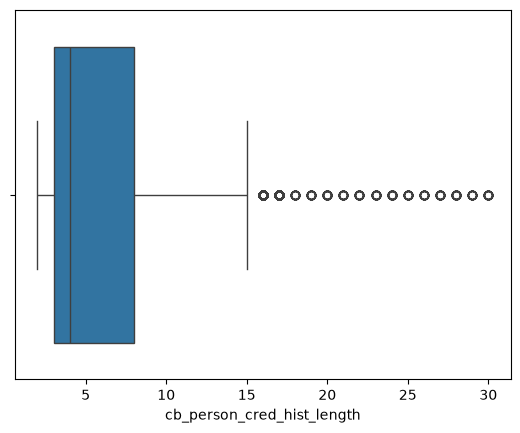

In [51]:
num_cols=df.select_dtypes(include=np.number)
num_cols.columns

for num in num_cols:
    sns.boxplot(x=df[num])

    plt.show()


In [52]:
(df['person_age']>100).sum()

np.int64(5)

In [53]:
# Now we will check the correlation 

<Axes: >

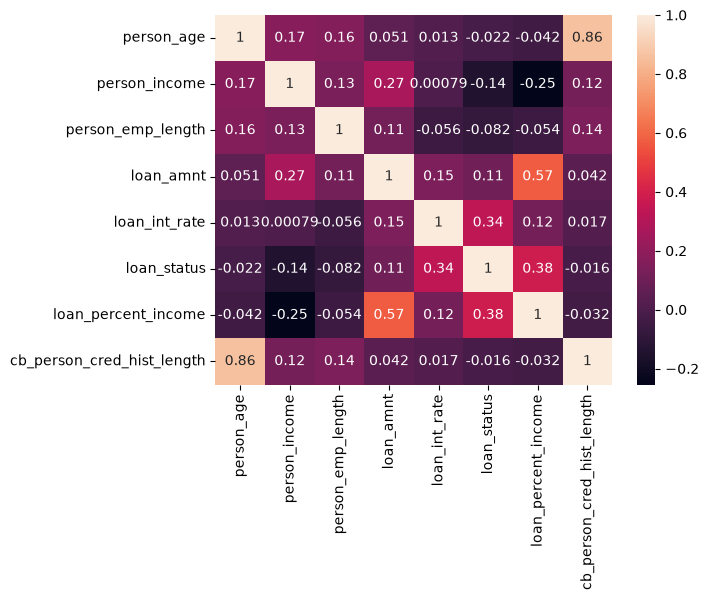

In [54]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [55]:
df_copy=df.copy()

 DATA CLEANING

In [56]:
df_copy = df.copy()

print(f"Original Rows: {df_copy.shape[0]}")

#Remove Duplicate rows
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates : {df_copy.shape[0]}")

#Remove ages below 18 or below 100
df_copy = df_copy[df_copy['person_age'] >=18]
df_copy = df_copy[df_copy['person_age'] <=100]

#Remove employment length greater than age or extreme outliers (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

#Remove the rows with zero or negative income and loan amount.
df_copy = df_copy[df_copy['loan_amnt'] > 0]

#check if the interest rate looks realistic.
print("Loan intreset rate range from (min: 5.42 and max: 23.22)")

Original Rows: 32581
Rows after removing duplicates : 32416
Loan intreset rate range from (min: 5.42 and max: 23.22)


In [57]:
df_copy.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31522.000000,3.152200e+04,31522.000000,31522.000000,28495.000000,31522.000000,31522.000000,31522.000000
mean,27.742529,6.650168e+04,4.782850,9663.771334,11.045220,0.215944,0.169658,5.816097
std,6.218713,5.275216e+04,4.037343,6334.787700,3.230786,0.411482,0.106296,4.063622
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.943800e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Train Test Split 

In [58]:
x=df_copy.drop('loan_status',axis=1)
y=df_copy['loan_status']

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42,stratify=y)

'''
stratify=y is used in train_test_split() to make sure the class/target distribution stays approximately the same in both training and testing data.
'''

# Extra note what normalize does i got this question so thought to share here 
# normalize=True = give me percentage/proportion instead of raw count

'\nstratify=y is used in train_test_split() to make sure the class/target distribution stays approximately the same in both training and testing data.\n'

In [60]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(21119, 11)
(10403, 11)
(21119,)
(10403,)


In [61]:
numerical_cols=x.select_dtypes(include=np.number).columns
categorical_cols=x.select_dtypes(include=['category','object']).columns

C:\Users\arpan\AppData\Local\Temp\ipykernel_25528\1699549630.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols=x.select_dtypes(include=['category','object']).columns


In [62]:
print("numerical_cols=",numerical_cols)
print("categorical_cols=",categorical_cols)

numerical_cols= Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='str')
categorical_cols= Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='str')


HANDLE CLASS IMBALANCE

In [63]:
print(y.value_counts(normalize=True))

loan_status
0    0.784056
1    0.215944
Name: proportion, dtype: float64


In [64]:
# To handle class imbalance, there are several techniques. Some commonly used techniques are:
# 1. Class Weights

# Give more importance to the minority class during model training, without changing the dataset.

# 2. Oversampling

# Increase the number of minority-class samples.

# Random Oversampling: duplicates existing minority samples.
# SMOTE: creates synthetic minority samples.
# 3. Undersampling

# Reduce the number of majority-class samples to make the classes more balanced.

# 4. Threshold Adjustment

# Change the classification probability threshold instead of always using the default 0.5, which can help improve recall for the minority class.

# 5. Combination Methods

# Combine techniques such as SMOTE + undersampling to handle severe class imbalance.

# 6. Use Appropriate Evaluation Metrics

# Accuracy alone can be misleading with imbalanced data, so use metrics such as Precision, Recall, F1-score, ROC-AUC, PR-AUC, and Confusion Matrix.

# Important: When using oversampling/SMOTE/undersampling, apply it only to the training data, not before the train-test split, to avoid data leakage.

In [65]:
# WE WILL USE THE WEIGHTS METHOD TO HANDLE CLASS IMBALANCE
#0 -> no loan (most)
#1 -> yes loan

# NOTE - XG BOOST DOES NOT HAEV INBUILT WEIGHTS THING BUT LOGISTIC REGRESSION HAD 

In [66]:
neg,pos=np.bincount(y_train)
scale_weigths=neg/pos
scale_weigths

np.float64(3.630344222758167)

DATA PREPROCESSING AND PIPELINE

1. Logistic Regression

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Missing"
    )),
    ("onehot", OneHotEncoder(handle_unknown="ignore")) #wtih using handle unknown it simply handles the unseen category without crashing.
])
preprocessor_lr = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])


# we can also do this directyly 
# preprocessor_lr = ColumnTransformer(
#     transformers=[
#         #Pipeline - for numerical cols
#         ('num', Pipeline([
#             ('imputer', SimpleImputer(strategy='median')),
#             ('scaler', StandardScaler())
#         ]), numeric_cols),

#         #Pipeline - for Categorical cols.
#         ('cat', Pipeline([
#             ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
#             ('onehot', OneHotEncoder(handle_unknown='ignore'))
#         ]), categorical_cols)
#     ])


2.XGBOOST


In [69]:
# XGBoost: Impute numeric only (No Scaling),
# impute + One-Hot Encoding for categorical

preprocessor_xg = ColumnTransformer(
    transformers=[
        
        # Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numerical_cols),

        # Pipeline - for categorical cols
        ('cat', Pipeline([
            ('imputer', SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)


# Why no StandardScaler?

# XGBoost is a tree-based model.

# Tree models split based on conditions such as:

# income < 50000
# income < 75000
# income < 100000

# So the actual scale of the feature isn't important.

# For example:

# income: 20,000 → 100,000

# doesn't need to become:

# -1.2 → 1.5 

In [70]:
X_train.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 2031
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [71]:
#STRATIFIE CROSS VALIDATATION -(USUALLY USED IN CLASSFICATION PROB ) but it is not necessary 
#we nned a lot of computation power so we use this in small dataset if nneeded or ot is optional 

In [82]:
from sklearn.model_selection import StratifiedKFold,cross_validate
cv=StratifiedKFold(n_splits=5,
                shuffle=True,
                random_state=42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [73]:
# LogisticRegression 



In [74]:
from sklearn.linear_model import LogisticRegression
cv_lr_pipeline= Pipeline([
    ('preprocessor',preprocessor_lr),
    ('classifier',LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42))
])
cv_lr_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [75]:
# XGBOOST

In [79]:
from xgboost import XGBClassifier

cv_xg_pipeline = Pipeline([
    ("preprocessor", preprocessor_xg),

    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=scale_weigths,
        random_state=42,
        n_jobs=-1
    ))
])
cv_xg_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [81]:
for cv_name, pipe in [("Logistic Regression", cv_lr_pipeline),("XGBoost", cv_xg_pipeline)]:
    print(cv_name,pipe)
    
    

Logistic Regression Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='str')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strat

In [83]:
cv_results = cross_validate(pipe, X_train , y_train, cv=cv, scoring=scoring, n_jobs=-1)

In [84]:
cv_results

{'fit_time': array([0.84556961, 0.84807444, 0.78262496, 0.82194972, 0.83253431]),
 'score_time': array([0.063416  , 0.07645154, 0.07519913, 0.07214808, 0.06328297]),
 'test_roc_auc': array([0.95028511, 0.945531  , 0.94520159, 0.94567016, 0.94872951]),
 'test_accuracy': array([0.91548295, 0.91950758, 0.91595644, 0.92282197, 0.91996211]),
 'test_precision': array([0.79935275, 0.82723112, 0.81901489, 0.83542857, 0.83064516]),
 'test_recall': array([0.8125    , 0.79276316, 0.78399123, 0.80065717, 0.79057018]),
 'test_f1': array([0.80587276, 0.80963046, 0.80112045, 0.81767338, 0.81011236])}

In [87]:
print(cv_name)

print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
print(f"Precision : {cv_results['test_precision'].mean()}")
print(f"Recall : {cv_results['test_recall'].mean()}")
print(f"F1 : {cv_results['test_f1'].mean()}")
                      
     

XGBoost
ROC-AUC : 0.9470834775851917
Accuracy : 0.9187462103272843
Precision : 0.822334499197852
Recall : 0.7960963471109318
F1 : 0.8088818803731103


BaseLINEMODEL LR

In [90]:
baseline_model=Pipeline([
    ('preprocessor',preprocessor_lr),
    ('classifier',LogisticRegression(class_weight='balanced'))
])
baseline_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['person_age','person_income','person_home_ownership',..., 'loan_percent_income','cb_person_default_on_file', 'cb_person_cred_hist_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

In [92]:
xg_boost=Pipeline([
    ('Preprocessor',preprocessor_xg),
    ('classifier', XGBClassifier(learning_rate=0.1,
        scale_pos_weight=scale_weigths,random_state=42))
])
xg_boost.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['person_age','person_income','person_home_ownership',..., 'loan_percent_income','cb_person_default_on_file', 'cb_person_cred_hist_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

Evaluation Helper Function

In [93]:
#We have to evaluate Logistic Model and XGBoost model on the basis of their metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve
def evaluate_model(model_name, model, X_test, y_test, threshold=None):
  y_pred_prob = model.predict_proba(X_test)[:,1]

  if threshold:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  #Metrics
  accuracy     = accuracy_score(y_test, y_pred)    #Overall model's preformance
  precision    = precision_score(y_test, y_pred)   #When the model says 1, how oftenly is it actually 1.
  recall       = recall_score(y_test, y_pred)      #of the actual 1 how many did the model catches
  f1           = f1_score(y_test, y_pred)          #Harmonic mean of precision and recall

  conf_matrix   = confusion_matrix(y_test, y_pred)
  class_report  = classification_report(y_test, y_pred)


  print(f"{model_name} Metrics:")
  if threshold is not None: # Only print threshold if provided
    print(f"Used Threshold : {threshold:.2f}")
  print(f"Accuracy : {accuracy:.2f}")
  print(f"Precision : {precision:.2f}")
  print(f"Recall : {recall:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)


  #Plotting confusion matrix
  sns.heatmap(conf_matrix, annot=True, fmt="d")
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()


  #Plotting ROC-AUC curve
  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()

Baseline Logistic Model Metrics:
Accuracy : 0.82
Precision : 0.55
Recall : 0.78
F1 : 0.65

Baseline Logistic Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      8157
           1       0.55      0.78      0.65      2246

    accuracy                           0.82     10403
   macro avg       0.74      0.80      0.76     10403
weighted avg       0.85      0.82      0.83     10403



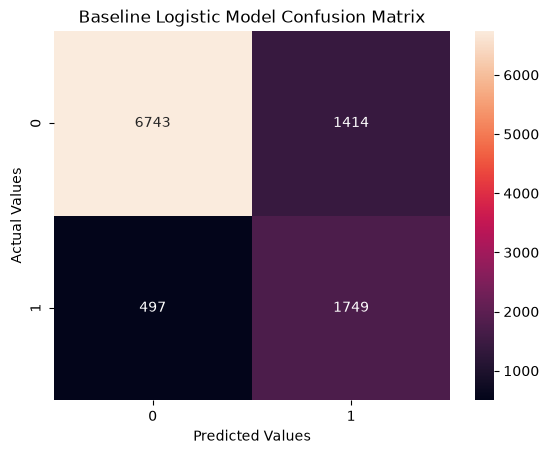

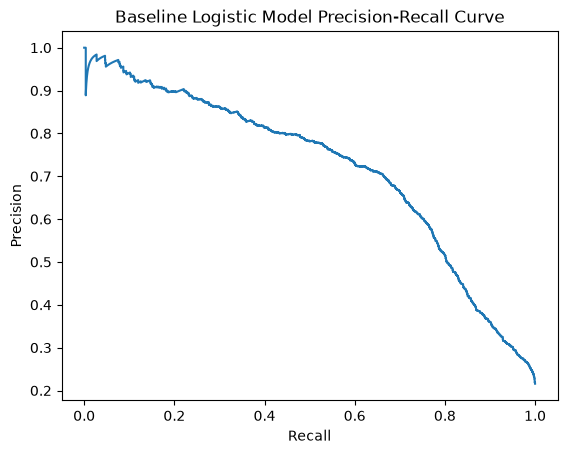

In [94]:
evaluate_model("Baseline Logistic Model", baseline_model ,X_test, y_test)

Xgboost Metrics:
Accuracy : 0.92
Precision : 0.83
Recall : 0.79
F1 : 0.81

Xgboost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      8157
           1       0.83      0.79      0.81      2246

    accuracy                           0.92     10403
   macro avg       0.88      0.87      0.88     10403
weighted avg       0.92      0.92      0.92     10403



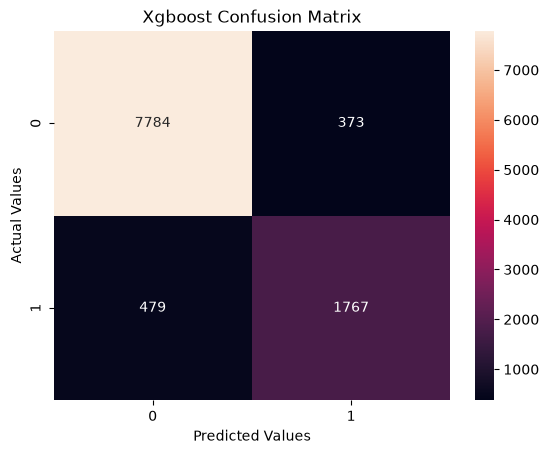

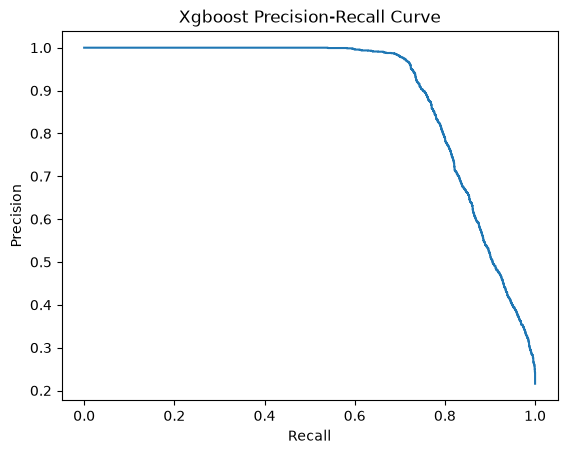

In [96]:
evaluate_model("Xgboost", xg_boost ,X_test, y_test)
     

HYPERPARAMETER TUNING USING OPTUNA